# Lab 1: Convolutional Neural Networks

This notebook contains the key concepts and steps to implementing a Convolutional Neural Network.
Implementing the tasks below should give you an idea of how this method for image classification works.

Using device: mps
Train set size: 50000
Test set size: 10000


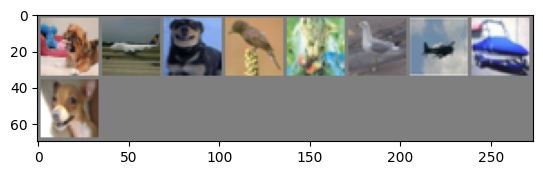

Labels: dog   plane dog   bird  cat   bird  plane ship  dog  

Starting training on GPU...
[1,   100] loss: 2.303
[1,   200] loss: 2.302
[1,   300] loss: 2.302
[1,   400] loss: 2.301
[1,   500] loss: 2.300
[1,   600] loss: 2.298
[1,   700] loss: 2.295
[2,   100] loss: 2.272
[2,   200] loss: 2.216
[2,   300] loss: 2.120
[2,   400] loss: 2.059
[2,   500] loss: 2.003
[2,   600] loss: 1.975
[2,   700] loss: 1.941
[3,   100] loss: 1.876
[3,   200] loss: 1.834
[3,   300] loss: 1.809
[3,   400] loss: 1.796
[3,   500] loss: 1.755
[3,   600] loss: 1.758
[3,   700] loss: 1.735
[4,   100] loss: 1.693
[4,   200] loss: 1.692
[4,   300] loss: 1.638
[4,   400] loss: 1.615
[4,   500] loss: 1.629
[4,   600] loss: 1.596
[4,   700] loss: 1.586
[5,   100] loss: 1.572
[5,   200] loss: 1.532
[5,   300] loss: 1.537
[5,   400] loss: 1.539
[5,   500] loss: 1.546
[5,   600] loss: 1.526
[5,   700] loss: 1.479
[6,   100] loss: 1.458
[6,   200] loss: 1.477
[6,   300] loss: 1.466
[6,   400] loss: 1.472
[6,   500] l

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
import numpy as np

class CustomCIFAR10(Dataset):
    def __init__(self, input_dataset, transform=None):
        self.input_dataset = input_dataset
        self.transform = transform

    def __len__(self):
        return len(self.input_dataset)

    def __getitem__(self, idx):
        sample, label = self.input_dataset[idx]
        if self.transform:
            sample = self.transform(sample)

        return sample, label


class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.dropout1 = nn.Dropout(0.25)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.dropout2 = nn.Dropout(0.25)
        self.flatten = nn.Flatten()
        self.dense1 = nn.Linear(64 * 8 * 8, 512)
        self.dropout3 = nn.Dropout(0.5)
        self.dense2 = nn.Linear(512, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool1(x)
        x = self.dropout1(x)
        
        x = F.relu(self.conv3(x))
        # identity = x
        x = self.conv4(x)
        # x = x + identity
        # x = F.relu(x)
        
        x = self.pool2(x)
        x = self.dropout2(x)
        x = self.flatten(x)
        x = F.relu(self.dense1(x))
        x = self.dropout3(x)
        x = self.dense2(x)
        return x

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

net = Net()
net = net.to(device)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True)
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True)

cifar10_trainset = CustomCIFAR10(trainset, transform=transform)
cifar10_testset = CustomCIFAR10(testset, transform=transform)

trainloader = DataLoader(cifar10_trainset, batch_size=64, shuffle=True, num_workers=0)
testloader = DataLoader(cifar10_testset, batch_size=64, shuffle=False, num_workers=0)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

print(f'Train set size: {len(trainset)}')
print(f'Test set size: {len(testset)}')

def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

dataiter = iter(trainloader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images[:9]))
print('Labels:', ' '.join(f'{classes[labels[j]]:5s}' for j in range(9)))

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

print("\nStarting training on GPU...")
for epoch in range(20):
    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if i % 1000 == 1999:
            print('[%d, %5d] loss: %.3f' %
                  (epoch + 1, i + 1, running_loss / 100))
            running_loss = 0.0

print('Finished Training')

print("\nEvaluating on GPU...")
correct = 0
total = 0
net.eval()
with torch.no_grad():
    for data in testloader:
        images, labels = data
        images, labels = images.to(device), labels.to(device)
        
        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print('Accuracy of the network on the 10000 test images: %d %%' % (
    100 * correct / total))

class_correct = list(0. for i in range(10))
class_total = list(0. for i in range(10))
with torch.no_grad():
    for data in testloader:
        images, labels = data
        images, labels = images.to(device), labels.to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)
        c = (predicted == labels).squeeze()
        for i in range(len(labels)):
            label = labels[i]
            class_correct[label] += c[i].item()
            class_total[label] += 1

print('\nPer-class accuracy:')
for i in range(10):
    print('Accuracy of %5s : %2d %%' % (
        classes[i], 100 * class_correct[i] / class_total[i]))